## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importing the dataset

In [2]:
dataset = pd.read_csv("F:\MA Team\First Dataset.csv")

In [3]:
dataset.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


## Droping the missing values by dropna() method

In [4]:
dataset = dataset.dropna()

## Checking and removing duplicates

In [5]:
dataset.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50    False
51    False
52    False
53    False
54    False
55    False
56    False
57    False
58    False
59    False
60     True
dtype: bool

In [6]:
dataset = dataset.drop_duplicates()

## Fixing 'gender' column problem

In [7]:
unique_names = {
    "Ali": "M",
    "Amir": "M",
    "Maryam": "F",
    "Kimia": "F",
    "Mina": "F",
    "Sara": "F",
    "Reza": "M",
    "Sina": "M",
    "Arash": "M",
    "Parsa": "M",
    "Neda": "F",
    "Zahra": "M",
}

In [8]:
dataset['gender'] = dataset['first_name'].map(unique_names)
dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
9,1010,Arash,M,145.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


## Outliers

### Detecting outliers

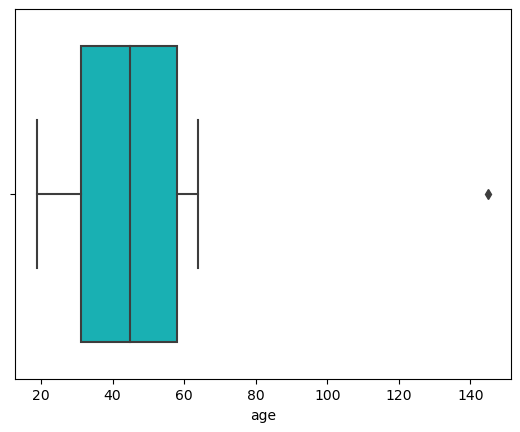

In [9]:
sns.boxplot(data=dataset, x='age', color='#00c9cc')
plt.show()

### IQR method for removing outliers

In [10]:
q1 = dataset['age'].quantile(0.25)
q3 = dataset['age'].quantile(0.75)
iqr = q3 - q1
print(q1, q3, iqr)

31.25 58.0 26.75


### Defining outliers based on IQR

In [11]:
upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)
print(upper_limit, lower_limit)

98.125 -8.875


In [12]:
outlier = dataset.loc[(dataset['age'] > upper_limit) | (dataset['age'] < lower_limit)]
outlier

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010,Arash,M,145.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


### Filtering the dataset to exclude outliers

In [13]:
final_dataset = dataset.drop(outlier.index)
final_dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
10,1011,Neda,F,41.0,Karaj,Alborz,2021-12-16,Bronze,19,119.16,2264.04,272,Card,Android,No,8,2


## Reseting index

In [14]:
final_dataset = final_dataset.reset_index(drop=True)
final_dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
9,1011,Neda,F,41.0,Karaj,Alborz,2021-12-16,Bronze,19,119.16,2264.04,272,Card,Android,No,8,2


## Exporting cleaned_dataset in xlsx format

In [15]:
final_dataset.to_excel(r'C:\Users\Asus\Downloads\cleaned_dataset_nana-in-wonderland.xlsx', index=False)

## Top 5 customers based on 'total_spending'

In [16]:
sorted_final_dataset = dataset.sort_values(by='total_spending', ascending=False)

In [17]:
sorted_final_dataset.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
29,1030,Sina,M,60.0,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.00,340,Cash,Web,Yes,4,4
43,1044,Mina,F,64.0,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,No,7,2
56,1057,Maryam,F,58.0,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4
11,1012,Arash,M,51.0,Mashhad,Khorasan,2023-07-22,Gold,27,434.50,11731.50,224,Online Wallet,iPhone,Yes,3,2
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2


## Which cities have more 'total_spending'?

#### *using double brackets returns a DataFrame*

In [18]:
city_grouped = final_dataset.groupby("city")[["total_spending"]].sum()

In [19]:
city_grouped.sort_values("total_spending", ascending=False)

,total_spending
city,
Mashhad,64118.44
Tabriz,36192.49
Ahvaz,23384.78
Shiraz,20715.92
Isfahan,18980.60
Karaj,18948.34
Rasht,15168.54
Tehran,13880.85


## Which payment mothod was used the most?

In [20]:
payment_method_grouped = final_dataset.groupby("payment_method")[["purchase_count"]].sum()

In [21]:
payment_method_grouped.sort_values("purchase_count", ascending=False)

,purchase_count
payment_method,
Cash,349
Online Wallet,321
Card,304


## Sorting devices based on 'total_spending'?

In [22]:
device_grouped = final_dataset.groupby("device")[["total_spending"]].sum()

In [23]:
device_grouped.sort_values("total_spending", ascending=False)

,total_spending
device,
Web,75881.34
iPhone,67931.01
Android,67577.61


## 'discount_used' VS. 'satisfaction_score'

In [24]:
discount_grouped = final_dataset.groupby("discount_used")[["purchase_count"]].sum()

In [25]:
discount_grouped.sort_values("purchase_count", ascending=False)

,purchase_count
discount_used,
No,569
Yes,405


In [26]:
satisfaction_grouped = final_dataset.groupby("discount_used")[["satisfaction_score"]].sum()

In [27]:
satisfaction_grouped.sort_values("discount_used", ascending=False)

,satisfaction_score
discount_used,
Yes,78
No,93


## Time series:
## During which time periods were sales higher?

### Ensuring about signup_date type:

In [28]:
final_dataset["signup_date"] = pd.to_datetime(final_dataset["signup_date"])

In [29]:
final_dataset["month"] = final_dataset["signup_date"].dt.month_name()
monthly_spending = final_dataset.groupby("month")["total_spending"].sum()

In [30]:
monthly_spending = monthly_spending.sort_values(ascending=False)
monthly_spending

month
July         32928.56
March        30383.00
May          25074.58
August       20519.29
June         20145.27
February     17507.32
November     16850.44
January      13436.07
September    13392.82
October       9902.92
December      7920.77
April         3328.92
Name: total_spending, dtype: float64

# The last step:
## A statistical summary of the cleaned dataset

In [31]:
final_dataset.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,1030.877193,43.280702,17.087719,213.744386,3708.595789,201.929825,4.210526,3.000000
std,17.609930,14.021354,10.170477,129.919511,4348.282835,95.903571,2.690837,1.414214
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1016.000000,31.000000,10.000000,108.190000,1161.920000,139.000000,2.000000,2.000000
50%,1031.000000,45.000000,17.000000,161.330000,2117.000000,205.000000,4.000000,3.000000
75%,1046.000000,58.000000,24.000000,323.320000,4615.050000,273.000000,7.000000,4.000000
max,1060.000000,64.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.000000
